# Calibrate A Day

This notebook performs calibration of a day's averaged spectrum. This is the same as `edges3.c`.

In [1]:
data_dir: str = '/data5/edges/data/EDGES3_data/MRO/'
year: int = 2023
day: int = 305
calfile: str = "/data4/vydula/edges/edges3-data-analysis/scripts/prefect-10days/specal.txt"
ants11file: str = "/data4/vydula/edges/edges3-data-analysis/scripts/prefect-10days/ants11_modelled.h5"
outputsdir: str = "/data4/vydula/edges/edges3-data-analysis/scripts/prefect-10days/prefect-outputs/"

alan_dir: str = "/data4/vydula/edges/edges3-data-analysis/scripts/alan_300_310_tests/"

fmin: float = 50   # Minimum freq to keep in the data       
fmax: float = 150  # Maximum freq to keep in the data

cal_freq_min: float = 51  # Minimum freq to *use* (i.e. with weight>0)
cal_freq_max: float = 119

do_beam_correction: bool = False
inject_beam: bool = False
    


## Imports and Data Load

In [2]:
from pathlib import Path
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un

from pygsdata import GSData
from pygsdata.select import select_freqs

from edges_cal import Calibrator
from edges_cal.alanmode import read_specal_as_calibrator
from edges_cal import modelling as mdl

from edges_analysis.calibration.calibrate import apply_beam_correction, apply_loss_correction, apply_noise_wave_calibration
from edges_analysis.averaging.freqbin import gauss_smooth
from edges_analysis.datamodel import add_model
from edges_analysis.filters import filters
from edges_pipelines import utils
from read_acq.cli import convert 

In [3]:
utils.print_versions()

Versions: 
            read_acq: 1.1.1.dev6+gb1a6b4d
            pygsdata: 0.2.2.dev6+ge6726b0
           edges-cal: 7.1.0
            edges-io: 4.1.9.dev5+g08d3eed
      edges-analysis: 6.0.3.dev96+gf2b3739


In [4]:
data_dir = Path(data_dir)
#alan_dir = Path(alan_dir) / str(utils.yday_to_alanday(year, day))

In [5]:
obsname = f"{year}_{day:>03}"

In [6]:
pre_cal_data = GSData.from_file(Path(outputsdir) / f"{obsname}.averaged.gsh5")


In [7]:
if calfile.endswith(".txt"):
    calobs = read_specal_as_calibrator(calfile, t_load=300, t_load_ns=1000)
else:
    calobs = Calibrator.from_calfile(calfile)

### Noise-Wave Calibration

In [8]:
nw_data = select_freqs(pre_cal_data, freq_range=(fmin, fmax))

/data4/vydula/edges/packages/pygsdata/src/pygsdata/select.py:79: UserWarning: frequency range given without units, assuming MHz.
  mask = freq_selector(data.freqs, freq_range=freq_range, indx=indx)


In [9]:
nw_data = filters.flag_frequency_ranges(nw_data, freq_ranges=((cal_freq_min, cal_freq_max),), invert=True)

In [10]:
#alan_pre_cal = np.genfromtxt(alan_output_dir/"spectra_before_noise_waves.txt")

In [11]:
nw_data = apply_noise_wave_calibration(
    nw_data,
    calobs = calobs,
    band='low',
    ant_s11_object=ants11file,
)

In [12]:
#alan_ants11 = np.genfromtxt(alan_output_dir/"modeled_antenna_s11.txt")

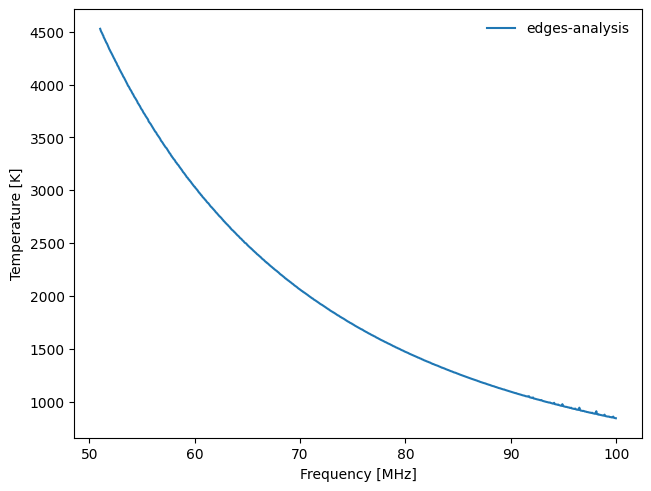

In [13]:
utils.plot_single_spectrum(nw_data)

### Loss-Correction

In [14]:
# # Apply different loss corrections
# loss_data = apply_loss_correction(
#     nw_data, 
#     ants11=ants11file, 
#     ambient_temp=296*un.K, 
#     loss_function=low2_balun_connector_loss, 
#     use_approx_eps0=True
# )
# # no antenna correction
# # no ground loss

In [15]:
#alan_spec_after_loss = np.genfromtxt(alan_output_dir / "spectra_after_loss.txt", names=True)

In [16]:
#utils.plot_single_spectrum(loss_data, alan_spec_after_loss['spec'])

### Beam Correction

In [17]:
if do_beam_correction:
    if inject_beam:
        beamfac = np.genfromtxt(alan_output_dir/'beamcorr.txt')
        beam_data = loss_data.update(data=loss_data.data * beamfac[:, 3])
    else:
        beam_data = apply_beam_correction(
            loss_data, 
            beam="/data4/nmahesh/edges/edges-field-levels/beam_factors/alan_newfc.h5",
            freq_model = mdl.Fourier(n_terms=31, transform=mdl.ShiftTransform(shift=75.0), period=72.0),
            resample_beam_lsts = False,
            integrate_before_ratio = True,
        )
else:
    beam_data = nw_data

In [18]:
# Get Alan's file after beam correction. NOTE: if beam correction is turned off in the script running the C-code, then this
# will NOT have beam correction actually applied, and will be the same as the previous plot.

#alan_after_beam = np.genfromtxt(alan_output_dir/"spectra_after_beam.txt", names=True)

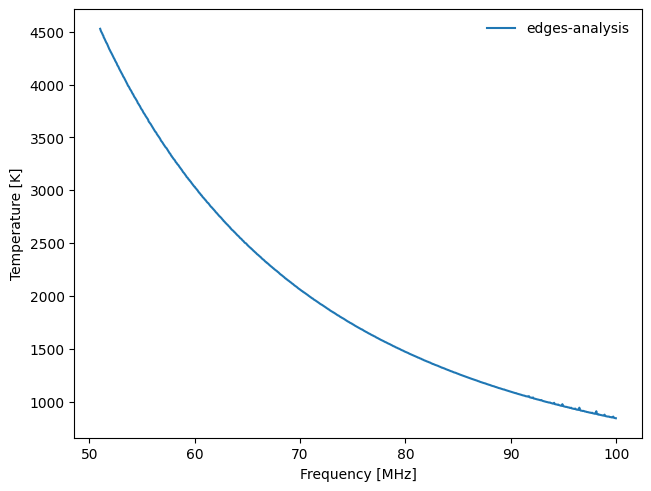

In [19]:
utils.plot_single_spectrum(beam_data) #, alan_after_beam['spec'])

### Smooth Over Frequencies Again

In [20]:
data = add_model(beam_data, model=mdl.PhysicalLin(n_terms=5, spectral_index=-2.55, f_center=85.0))

In [21]:
#alan_mdl = np.genfromtxt(alan_output_dir /"second_smooth_input.txt", names=True)

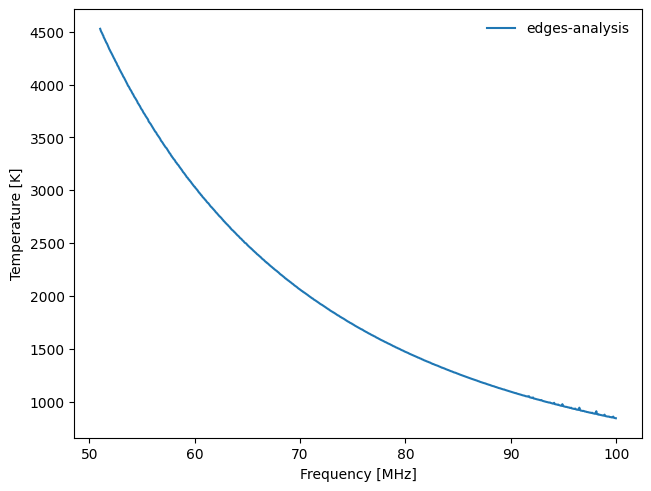

In [22]:
utils.plot_single_spectrum(data) #, alan_mdl['model'], attribute='model')

In [23]:
data = gauss_smooth(data, size=8, nsmooth=2, decimate_at=0, use_residuals=True, use_nsamples=False)

/data4/vydula/edges/packages/edges-analysis/src/edges_analysis/averaging/freqbin.py:141: RuntimeWarning: invalid value encountered in divide
  nsamples[nsamples / maxn <= size * flag_threshold] = 0


In [24]:
#alan_specavg = np.genfromtxt(alan_output_dir / "specavg_cal.txt", usecols=(1,3,9))

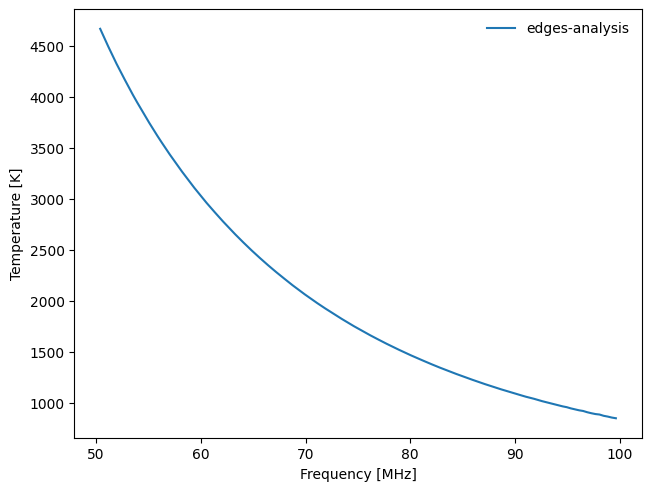

In [25]:
utils.plot_single_spectrum(data) #, alan_specavg[:, 1])

In [26]:
data.write_gsh5(Path(outputsdir) / f"{obsname}.finalspec.gsh5");

(<Axes: title={'center': '2023:304'}, xlabel='Frequency [MHz]', ylabel='JD'>,
 <matplotlib.colorbar.Colorbar at 0x7fe4f3907490>)

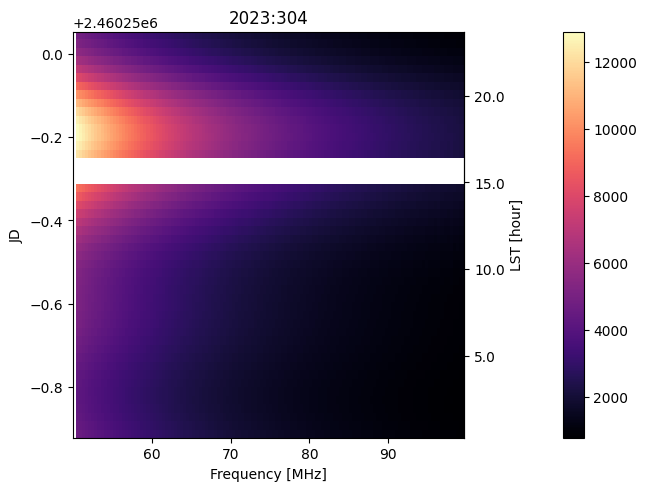

In [28]:
from pygsdata import plots
plots.plot_waterfall(data)